# Exploración: Importación de Vehículos (Portal SAT)

Este notebook consume el dataset unificado generado por el pipeline en
`../main.py` (`Datos/importacion_vehiculos.csv`) y responde las preguntas
de negocio de la fase de exploración.

**Mapeo de categorías usado en este análisis** (según `Tipo_Vehiculo`,
verificado contra `Marca`/`Linea` reales en los datos):

| Categoría de negocio | `Tipo_Vehiculo` en el dataset |
|---|---|
| Carros | `AUTOMOVIL` (ej. Mazda 3, Civic, Prius) |
| Pickups | `PICK UP` (ej. Tacoma, Ranger, Frontier) |
| SUV | `CAMIONETA` (ej. RAV4, Santa Fe, X1, Q7) |

**Nota sobre "el año pasado"**: se usa 2025 como año de referencia
("año pasado") y 2026 como año en curso, según la fecha de hoy.

**Nota de calidad de datos**: el archivo de junio 2026 incluye pólizas con
fecha real de julio 2026 (el archivo se publica días después del cierre
de mes), por lo que `Mes == 7` de 2026 está incompleto. Para la
comparación año-actual vs año-anterior (pregunta 5) se usan solo los
meses 1-6, que son los que tenemos completos en ambos años.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)

## 0. Carga del dataset unificado

In [2]:
DATASET_PATH = "../Datos/importacion_vehiculos.csv"

df = pd.read_csv(DATASET_PATH, parse_dates=["Fecha_Poliza"])
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
df.head()

Filas: 1,078,487 | Columnas: 19


,Pais_Proveniencia,Aduana_Ingreso,Fecha_Poliza,Partida_Arancelaria,Modelo_Vehiculo,Marca,Linea,Centimetros_Cubicos,Distintivo,Tipo_Vehiculo,Tipo_Importador,Tipo_Combustible,Asientos,Puertas,Tonelaje,Valor_CIF,Impuesto,Anio,Mes
0,ESTADOS UNIDOS,TECUN UMAN,2025-01-10,8704100000,1974,PETERBILT,359-A,14000.0,PESADO,CAMION VOLTEO,OCASIONAL,DIESEL,2.0,2.0,20.0,33325.78,3999.09,2025,1
1,JAPON,TECUN UMAN,2025-01-08,8703237991,2003,HONDA,CR-V EX 4WD,2400.0,LIVIANO,CAMIONETA,OCASIONAL,GASOLINA,5.0,4.0,0.0,42759.58,5131.15,2025,1
2,ESTADOS UNIDOS,TECUN UMAN,2025-01-08,8704315100,1994,TOYOTA,REG CAB 4X2,2400.0,LIVIANO,PICK UP,OCASIONAL,GASOLINA,3.0,2.0,1.0,32527.90,3903.35,2025,1
3,ESTADOS UNIDOS,TECUN UMAN,2025-01-08,8704315100,1980,TOYOTA,REG CAB 4X2,2200.0,LIVIANO,PICK UP,OCASIONAL,GASOLINA,3.0,2.0,1.0,32527.90,3903.35,2025,1
4,JAPON,TECUN UMAN,2025-01-09,8704315100,1986,TOYOTA,REG CAB 4WD,2400.0,LIVIANO,PICK UP,OCASIONAL,GASOLINA,3.0,2.0,1.0,21425.18,2571.02,2025,1


In [3]:
ANIO_ANTERIOR = 2025
ANIO_ACTUAL = 2026

MAPA_CATEGORIA = {
    "AUTOMOVIL": "Carros",
    "PICK UP": "Pickups",
    "CAMIONETA": "SUV",
}

livianos = df[df["Distintivo"] == "LIVIANO"].copy()
print(f"Vehículos livianos en todo el dataset: {len(livianos):,}")

Vehículos livianos en todo el dataset: 980,976


## 1. ¿Cuántos vehículos livianos de cada tipo se importaron en 2025?

In [4]:
livianos_2025 = livianos[livianos["Anio"] == ANIO_ANTERIOR]

conteo_tipo_2025 = (
    livianos_2025["Tipo_Vehiculo"]
    .value_counts()
    .rename("Cantidad")
    .to_frame()
)
conteo_tipo_2025

,Cantidad
Tipo_Vehiculo,
MOTO,508620
CAMIONETA,60821
PICK UP,48907
AUTOMOVIL,34634
TRIMOTO,14256
MICROBUS,1960
CAMIONETILLA,1789
PANEL,925
JEEP,846


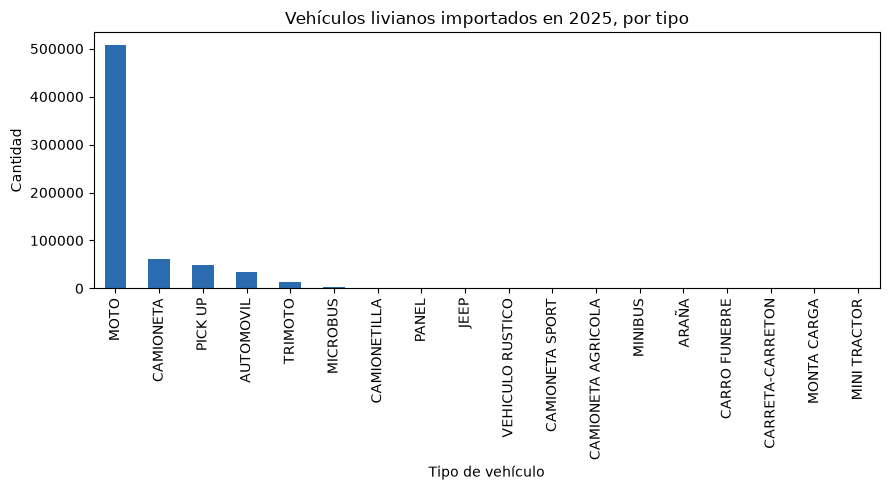

In [5]:
ax = conteo_tipo_2025["Cantidad"].plot(kind="bar", color="#2b6cb0")
ax.set_title(f"Vehículos livianos importados en {ANIO_ANTERIOR}, por tipo")
ax.set_xlabel("Tipo de vehículo")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 2. Distribución de modelos (año-modelo) de carros, pickups y SUV importados el año pasado

`Modelo_Vehiculo` es el año-modelo del vehículo (ej. 2020, 2021...), no el
nombre/línea comercial. Se filtran años-modelo fuera de un rango plausible
(1990-2027) porque el dataset trae algunos valores de captura errónea
(ej. 1900, 3351) que distorsionarían la gráfica.

In [6]:
categorias_2025 = livianos_2025[livianos_2025["Tipo_Vehiculo"].isin(MAPA_CATEGORIA)].copy()
categorias_2025["Categoria"] = categorias_2025["Tipo_Vehiculo"].map(MAPA_CATEGORIA)

RANGO_MODELO_VALIDO = (1990, 2027)
fuera_de_rango = ~categorias_2025["Modelo_Vehiculo"].between(*RANGO_MODELO_VALIDO)
print(f"Registros con año-modelo fuera de {RANGO_MODELO_VALIDO} (excluidos de la gráfica): "
      f"{fuera_de_rango.sum():,} de {len(categorias_2025):,}")

categorias_2025_validas = categorias_2025[~fuera_de_rango]

distribucion_modelo = (
    categorias_2025_validas
    .groupby(["Categoria", "Modelo_Vehiculo"])
    .size()
    .rename("Cantidad")
    .reset_index()
)
distribucion_modelo.pivot(index="Modelo_Vehiculo", columns="Categoria", values="Cantidad").tail(15)

Registros con año-modelo fuera de (1990, 2027) (excluidos de la gráfica): 7,021 de 144,362


Categoria,Carros,Pickups,SUV
Modelo_Vehiculo,,,
2013,3359.0,414.0,3079.0
2014,2968.0,415.0,3517.0
2015,2655.0,463.0,3627.0
2016,2047.0,435.0,4017.0
2017,1265.0,418.0,2156.0
2018,758.0,296.0,2209.0
2019,493.0,346.0,1481.0
2020,433.0,284.0,975.0
2021,290.0,310.0,1191.0


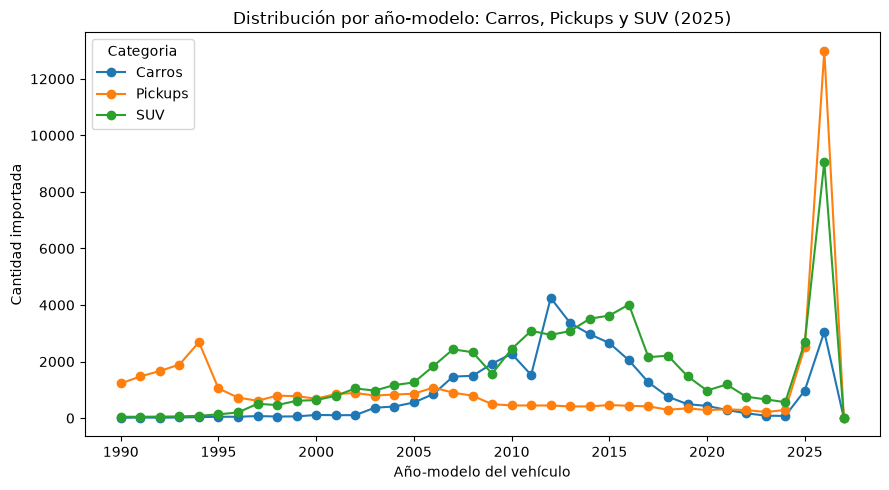

In [7]:
pivot_modelo = distribucion_modelo.pivot(index="Modelo_Vehiculo", columns="Categoria", values="Cantidad").fillna(0)

ax = pivot_modelo.plot(kind="line", marker="o")
ax.set_title(f"Distribución por año-modelo: Carros, Pickups y SUV ({ANIO_ANTERIOR})")
ax.set_xlabel("Año-modelo del vehículo")
ax.set_ylabel("Cantidad importada")
plt.tight_layout()
plt.show()

## 3. ¿Cuál es el tipo de vehículo que más se importó el año pasado?

Aquí se consideran **todos** los vehículos de 2025 (livianos y pesados),
no solo livianos, para responder la pregunta de forma completa.

In [8]:
todos_2025 = df[df["Anio"] == ANIO_ANTERIOR]
conteo_general_2025 = todos_2025["Tipo_Vehiculo"].value_counts()

tipo_mas_importado = conteo_general_2025.idxmax()
cantidad_mas_importado = conteo_general_2025.max()
print(f"Tipo de vehículo más importado en {ANIO_ANTERIOR}: {tipo_mas_importado} "
      f"({cantidad_mas_importado:,} unidades)")

conteo_general_2025.head(10)

Tipo de vehículo más importado en 2025: MOTO (508,620 unidades)


Tipo_Vehiculo
MOTO          508620
CAMIONETA      60822
PICK UP        48907
AUTOMOVIL      34634
CAMION         17753
CUATRIMOTO     14604
TRIMOTO        14256
CABEZAL         9061
SCOOTER         6350
MICROBUS        3255
Name: count, dtype: int64

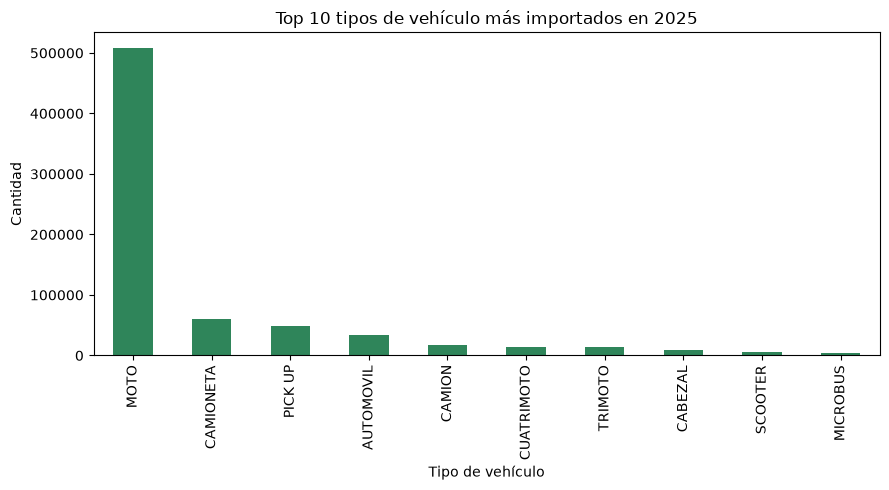

In [9]:
ax = conteo_general_2025.head(10).plot(kind="bar", color="#2f855a")
ax.set_title(f"Top 10 tipos de vehículo más importados en {ANIO_ANTERIOR}")
ax.set_xlabel("Tipo de vehículo")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 4. ¿Cuáles son los meses en los que más se importan vehículos livianos?

In [10]:
NOMBRES_MES = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
    7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre",
}

livianos_por_mes_2025 = (
    livianos_2025.groupby("Mes").size().rename("Cantidad").reset_index()
)
livianos_por_mes_2025["Mes_nombre"] = livianos_por_mes_2025["Mes"].map(NOMBRES_MES)
livianos_por_mes_2025 = livianos_por_mes_2025.sort_values("Cantidad", ascending=False)
livianos_por_mes_2025[["Mes_nombre", "Cantidad"]]

,Mes_nombre,Cantidad
8,Septiembre,63281
6,Julio,62781
9,Octubre,62597
0,Enero,59474
7,Agosto,58317
3,Abril,56978
11,Diciembre,56762
1,Febrero,55608
4,Mayo,54755
5,Junio,54317


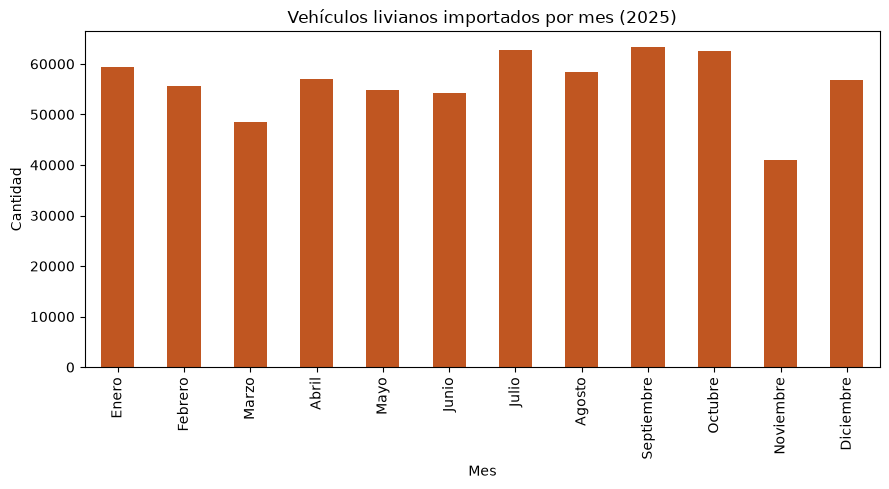

Mes con más importaciones de livianos en 2025: Septiembre (63,281 unidades)


In [11]:
orden_calendario = livianos_por_mes_2025.sort_values("Mes")
ax = orden_calendario.plot(x="Mes_nombre", y="Cantidad", kind="bar", legend=False, color="#c05621")
ax.set_title(f"Vehículos livianos importados por mes ({ANIO_ANTERIOR})")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

mes_pico = livianos_por_mes_2025.iloc[0]
print(f"Mes con más importaciones de livianos en {ANIO_ANTERIOR}: "
      f"{mes_pico['Mes_nombre']} ({mes_pico['Cantidad']:,} unidades)")

## 5. Importación por tipo de vehículo: meses transcurridos de 2026 vs mismo periodo de 2025

Se comparan enero-junio de ambos años (los 6 meses completos que tenemos
descargados de 2026), para todos los tipos de vehículo.

In [12]:
MESES_YTD = list(range(1, 7))  # Enero-Junio

ytd = df[df["Mes"].isin(MESES_YTD) & df["Anio"].isin([ANIO_ANTERIOR, ANIO_ACTUAL])]

comparacion = (
    ytd.groupby(["Tipo_Vehiculo", "Anio"]).size().unstack("Anio").fillna(0).astype(int)
)
comparacion["Variacion_%"] = (
    (comparacion[ANIO_ACTUAL] - comparacion[ANIO_ANTERIOR]) / comparacion[ANIO_ANTERIOR] * 100
).round(1)
comparacion = comparacion.sort_values(ANIO_ANTERIOR, ascending=False)
comparacion.head(15)

Anio,2025,2026,Variacion_%
Tipo_Vehiculo,,,
MOTO,250830,198439,-20.9
CAMIONETA,29197,34362,17.7
PICK UP,21760,26578,22.1
AUTOMOVIL,16823,18569,10.4
CAMION,8539,10277,20.4
TRIMOTO,7705,7090,-8.0
CUATRIMOTO,6635,7710,16.2
CABEZAL,3726,4542,21.9
SCOOTER,2700,3504,29.8


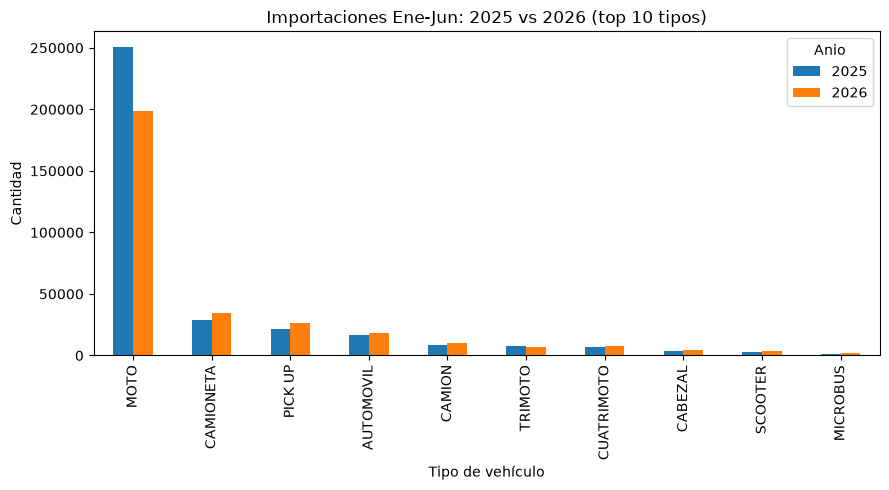

In [13]:
top_tipos = comparacion.head(10).drop(columns="Variacion_%")

ax = top_tipos.plot(kind="bar")
ax.set_title(f"Importaciones Ene-Jun: {ANIO_ANTERIOR} vs {ANIO_ACTUAL} (top 10 tipos)")
ax.set_xlabel("Tipo de vehículo")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

In [14]:
total_anterior = ytd[ytd["Anio"] == ANIO_ANTERIOR].shape[0]
total_actual = ytd[ytd["Anio"] == ANIO_ACTUAL].shape[0]
variacion_total = (total_actual - total_anterior) / total_anterior * 100

print(f"Total Ene-Jun {ANIO_ANTERIOR}: {total_anterior:,}")
print(f"Total Ene-Jun {ANIO_ACTUAL}: {total_actual:,}")
print(f"Variación total: {variacion_total:+.1f}%")

Total Ene-Jun 2025: 357,685
Total Ene-Jun 2026: 322,112
Variación total: -9.9%
